Problem Statement:
Write a Python program to draw (visualize) the architecture of a Neural Network used to classify fraudulent and non-fraudulent credit card transactions.

Python program visualizes a Neural Network architecture for Credit Card Fraud Detection using Matplotlib.
Neural Network Architecture
Input Layer (6 Features) -
TransactionAmount,
TransactionTime,
MerchantCategory,
CustomerAge,
AccountBalance, and
NumberOfTransactionsToday

Hidden Layer 1: 8 Neurons,
Hidden Layer 2: 6 Neurons,
Output Layer: 1 Neuron

0 = Genuine Transaction,
1 = Fraudulent Transaction

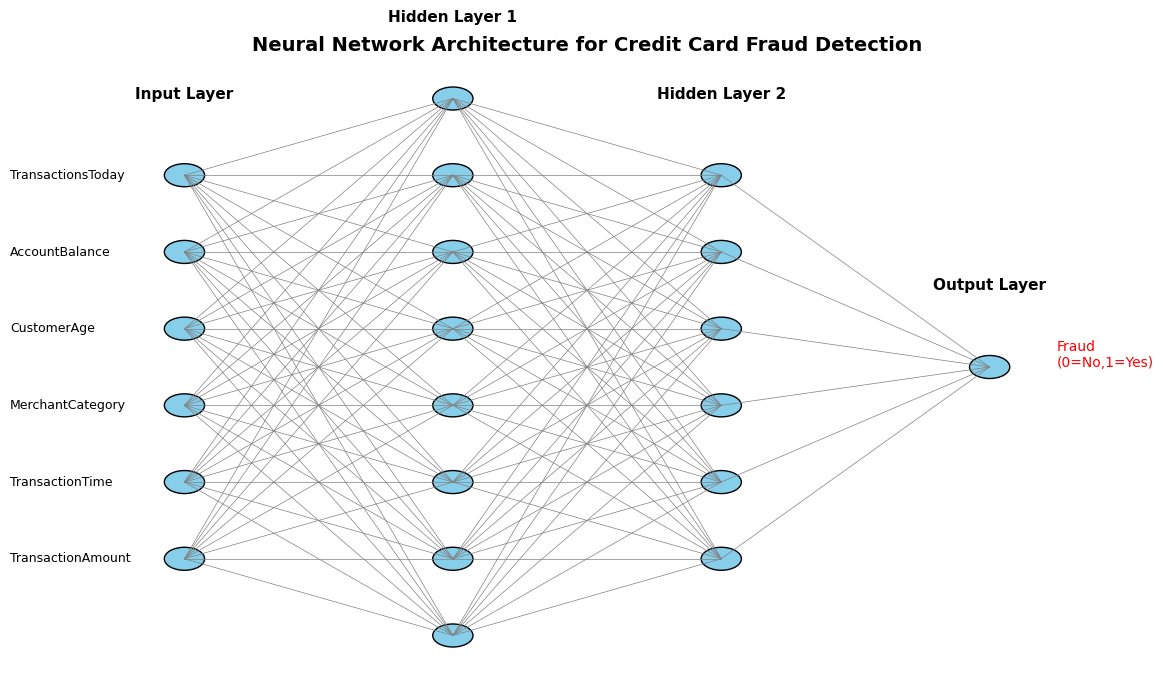

In [ ]:
import matplotlib.pyplot as plt

# Number of neurons in each layer
layers = {
    "Input Layer": 6,
    "Hidden Layer 1": 8,
    "Hidden Layer 2": 6,
    "Output Layer": 1
}

# X positions of layers
x_positions = [0, 2, 4, 6]

plt.figure(figsize=(12, 8))

layer_nodes = []

# Draw nodes
for i, (layer_name, num_nodes) in enumerate(layers.items()):

    y_positions = list(range(num_nodes))

    # Center align layers
    y_positions = [y - (num_nodes-1)/2 for y in y_positions]

    layer_nodes.append(
        [(x_positions[i], y) for y in y_positions]
    )

    for x, y in layer_nodes[-1]:
        circle = plt.Circle((x, y), 0.15,
                            color='skyblue',
                            ec='black')
        plt.gca().add_patch(circle)

    plt.text(x_positions[i],
             max(y_positions)+1,
             layer_name,
             ha='center',
             fontsize=11,
             fontweight='bold')

# Draw connections
for i in range(len(layer_nodes) - 1):
    for x1, y1 in layer_nodes[i]:
        for x2, y2 in layer_nodes[i+1]:
            plt.plot([x1, x2], [y1, y2], color='gray', linewidth=0.5)


# Input Feature Labels
input_features = [
    "TransactionAmount",
    "TransactionTime",
    "MerchantCategory",
    "CustomerAge",
    "AccountBalance",
    "TransactionsToday"
]

for idx, feature in enumerate(input_features):
    x, y = layer_nodes[0][idx]
    plt.text(x-1.3,
             y,
             feature,
             fontsize=9,
             va='center')

# Output Labels
x, y = layer_nodes[-1][0]

plt.text(x+0.5, y,
         "Fraud\n(0=No,1=Yes)",
         fontsize=10,
         color='red')

plt.axis('off')
plt.title("Neural Network Architecture for Credit Card Fraud Detection",
          fontsize=14,
          fontweight='bold')

plt.show()

Alternative (Using TensorFlow/Keras)
This code creates the actual neural network model and displays its summary.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(8,
                input_dim=6,
                activation='relu'))

# Hidden Layer 2
model.add(Dense(6,
                activation='relu'))

# Output Layer
model.add(Dense(1,
                activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117 (468.00 B)

 Trainable params: 117 (468.00 B)

 Non-trainable params: 0 (0.00 B)

Expected Architecture:
Input Layer (6 Features)
          │
          ▼
Hidden Layer 1 (8 Neurons)
          │
          ▼
Hidden Layer 2 (6 Neurons)
          │
          ▼
Output Layer (1 Neuron)
          │
          ▼
Fraud Prediction
(0 = Genuine, 1 = Fraud)
Explanation

Input Layer: Receives transaction details.
Hidden Layers: Learn patterns associated with fraudulent behavior.
ReLU Activation: Introduces non-linearity and improves learning.
Sigmoid Output: Produces a probability between 0 and 1 for fraud prediction.
Binary Classification: Classifies transactions as Genuine or Fraudulent.